1IAST - Fase 1 - Tech Challenge
Aluna: Janaina de Araujo Silva
RM: 375750

Preparação dos dados:

**01 - Configuração do Ambiente**

In [50]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import gdown

# Configuração de visualização do Pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 100)

# Paleta inspirada na identidade visual da FIAP
ROSA_FIAP = "#ED145B"
PRETO_FIAP = "#0B0B0B"
BRANCO = "#FFFFFF"
CINZA = "#A6A6A6"
CINZA_ESCURO = "#404040"

PALETA_FIAP = [
    ROSA_FIAP,
    BRANCO,
    CINZA,
    CINZA_ESCURO,
    "#F06292"
]

# Configuração padrão do Plotly
px.defaults.template = "plotly_dark"
px.defaults.color_discrete_sequence = PALETA_FIAP

**02 - Função para os gráficos**

**03 - Download da Base de Dados**

In [51]:
ID_BASE = "1tSJWm-TH4qVyJofO7TxGDTBHBU9S1QI4"

gdown.download(
    id=ID_BASE,
    output="desafio_nps_fase_1.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1tSJWm-TH4qVyJofO7TxGDTBHBU9S1QI4
To: /content/desafio_nps_fase_1.csv
100%|██████████| 175k/175k [00:00<00:00, 54.8MB/s]


'desafio_nps_fase_1.csv'

**04 - Carregamento dos Dados**

In [52]:
df = pd.read_csv("desafio_nps_fase_1.csv")

In [12]:
df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


Para confirmar quantidade de linhas e colunas

In [53]:
df.shape

(2500, 19)

Analisando a qualidade dos dados

In [54]:
import numpy as np
from scipy import stats

Verificando se existem dados nulos na base

In [55]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [56]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customer_id,1,2,3,4,5,6,7,8,9,10
customer_age,63,20,46,52,56,35,37,60,40,51
customer_region,Nordeste,Sul,Nordeste,Centro-Oeste,Norte,Sudeste,Sudeste,Sul,Sul,Sudeste
customer_tenure_months,14,1,111,117,50,75,68,37,60,70
order_id,50001,50002,50003,50004,50005,50006,50007,50008,50009,50010
order_value,139.73,458.95,507.06,302.19,253.06,568.76,41.29,428.76,121.56,411.01
items_quantity,4,2,5,2,1,6,3,4,3,6
discount_value,39.35,9.51,42.82,19.58,29.37,36.58,99.62,29.54,91.95,37.47
payment_installments,4,10,6,9,11,3,6,10,6,3
delivery_time_days,2,6,6,5,13,4,8,11,6,9


Entendendo o tipo de dados, valores núlos e quantidade de registros para cada coluna.

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

Verificando se há valores auxentes


In [58]:
df.isna().sum().sort_values(ascending=False)

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


Verificando Duplicidade dos dados

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
colunas_numericas =[
    "customer_tenure_months",
   "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days"
    ]

df[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00
freight_value,2500.0,38.217016,12.076074,2.62,29.9275,38.500,46.2700,76.13
delivery_attempts,2500.0,2.005600,0.815497,1.00,1.0000,2.000,3.0000,3.00
customer_service_contacts,2500.0,1.519600,1.231512,0.00,1.0000,1.000,2.0000,7.00


Construindo uma amostra aleatória

In [61]:
np.random.seed(42)
sample = df.sample(n=1000, replace=False)

In [62]:
df.describe()# população

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [63]:
sample.describe() #amostra

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,1000.00000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1245.01600,43.60600,61.172000,51245.01600,427.632220,3.484000,29.190100,6.096000,7.983000,2.198000,38.661090,1.995000,1.530000,5.365000,4.416800,0.091000,4.152000,2.999200
std,722.28671,14.76451,34.645616,722.28671,287.971102,1.699009,29.219433,3.098126,3.809623,1.452896,11.912231,0.810946,1.197721,3.468401,2.512782,0.287753,1.752703,2.388213
min,9.00000,18.00000,1.000000,50009.00000,14.580000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,585.50000,31.00000,31.000000,50585.50000,214.300000,2.000000,8.327500,3.000000,5.000000,1.000000,30.642500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.800000
50%,1261.50000,43.00000,62.000000,51261.50000,368.285000,3.000000,20.190000,6.000000,8.000000,2.000000,38.550000,2.000000,1.000000,5.000000,4.300000,0.000000,4.000000,2.800000
75%,1884.75000,56.00000,89.000000,51884.75000,569.817500,5.000000,40.772500,9.000000,11.000000,3.000000,46.557500,3.000000,2.000000,8.000000,6.200000,0.000000,5.000000,4.800000
max,2500.00000,69.00000,119.000000,52500.00000,1983.810000,6.000000,207.470000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [64]:
# Statística
sample_mean = sample['nps_score'].mean()
sample_std = sample['nps_score'].std(ddof=1) # desvio padrão amostral(DDOF). Sendo iguel a 1 pega informações da amostra. Iguel a Zero, está pegando da população.
n=len(sample)

In [65]:
sample_mean

np.float64(4.416799999999999)

<Axes: >

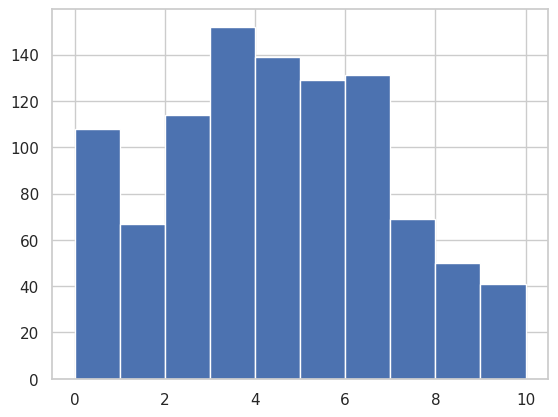

In [66]:
sample['nps_score'].hist()



In [67]:
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste Shapiro-Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    # Plot histograma
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(data, bins=10)
    plt.title("Histograma")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot")

    plt.show()

    # Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f}  a  {ci_bootstrap[1]:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")

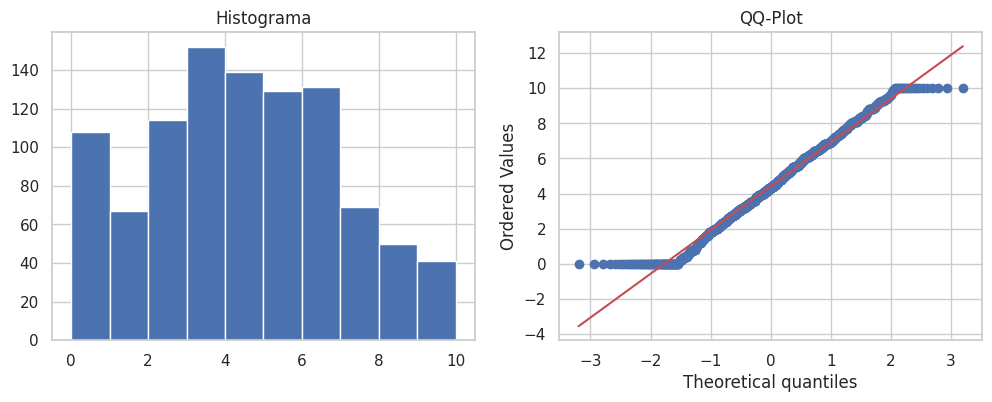

Média da amostra: 4.417
IC Bootstrap (95%): 4.259  a  4.570
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [68]:
analyze_distribution_and_ci(sample['nps_score']) #Amostra normal

In [69]:
sample['nps_score'].median()

4.3

In [70]:
nps_medio_regiao = (
    df.groupby('customer_region')['nps_score']
    .mean()
    .reset_index()
    .rename(
        columns={
            'customer_region': 'Região',
            'nps_score': 'Média NPS',
        }
    )
    .sort_values(by='Média NPS', ascending=False)
)

print(nps_medio_regiao)

         Região  Média NPS
4           Sul   4.490979
1      Nordeste   4.421649
2         Norte   4.382609
3       Sudeste   4.373846
0  Centro-Oeste   4.209829


/tmp/ipykernel_471/3302131059.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


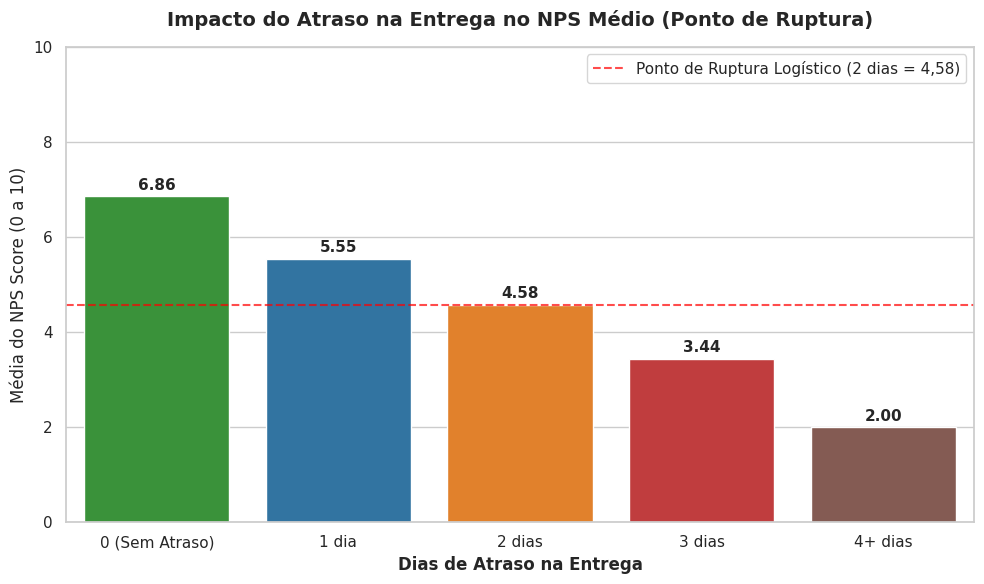

In [71]:




# 1. Carregar a planilha
df = pd.read_csv('desafio_nps_fase_1.csv')
df['atraso_categoria'] = df['delivery_delay_days'].apply(
    lambda x: '0 (Sem Atraso)' if x == 0 else (
        '1 dia' if x == 1 else (
            '2 dias' if x == 2 else (
                '3 dias' if x == 3 else '4+ dias'
            )
        )
    )
)

# 3. Ordenar as categorias
ordem_categorias = ['0 (Sem Atraso)', '1 dia', '2 dias', '3 dias', '4+ dias']
df_atraso = df.groupby('atraso_categoria')['nps_score'].mean().reindex(ordem_categorias).reset_index()

# 4. Configuração visual do gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Cores graduais destacando a deterioração da nota
cores = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#8c564b']

ax = sns.barplot(
    data=df_atraso,
    x='atraso_categoria',
    y='nps_score',
    palette=cores
)

# 5. Adicionar os valores exatos no topo de cada barra
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8), textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

# 6. Destacar o Ponto de Ruptura (2 dias de atraso)
plt.axhline(
    y=4.58,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Ponto de Ruptura Logístico (2 dias = 4,58)'
)

# Títulos e eixos
plt.title('Impacto do Atraso na Entrega no NPS Médio (Ponto de Ruptura)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Dias de Atraso na Entrega', fontsize=12, fontweight='bold')
plt.ylabel('Média do NPS Score (0 a 10)', fontsize=12)
plt.ylim(0, 10)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [72]:




# 1. Carregar a base de dados
df = pd.read_csv('desafio_nps_fase_1.csv')

# --- PARTE 1: NPS Médio por faixas de Atendimento (customer_service_contacts) ---

# NPS médio para clientes SEM contato (0 contatos)
nps_0_contatos = df[df['customer_service_contacts'] == 0]['nps_score'].mean()

# NPS médio a partir de 3 contatos (3 a 5 contatos)
nps_3_contatos = df[df['customer_service_contacts'] == 3]['nps_score'].mean()

# NPS médio para 6 ou mais contatos
nps_6_mais_contatos = df[df['customer_service_contacts'] >= 6]['nps_score'].mean()

print("--- RESULTADOS DO ATENDIMENTO (SAC) ---")
print("")
print(f"NPS Médio (0 contatos): {nps_0_contatos:.2f}")
print(f"NPS Médio (3º contato): {nps_3_contatos:.2f}")
print(f"NPS Médio (6+ contatos): {nps_6_mais_contatos:.2f}")


# --- PARTE 2: Correlação entre Reclamações e NPS ---

correlacao_reclamacoes = df['complaints_count'].corr(df['nps_score'])

print("\n--- CORRELAÇÃO ---")
print(f"Correlação (Reclamações x NPS): {correlacao_reclamacoes:.2f}")


# --- PARTE 3: Agrupamento em tabela e Gráfico ---

# Criar faixas personalizadas para visualização
df['sac_grupo'] = df['customer_service_contacts'].apply(
    lambda x: '0 Contatos' if x == 0 else (
        '1 Contato' if x == 1 else (
            '2 Contatos' if x == 2 else (
                '3 a 5 Contatos' if 3 <= x <= 5 else '6+ Contatos'
            )
        )
    )
)

# Tabela consolidada com contagem e média
ordem = ['0 Contatos', '1 Contato', '2 Contatos', '3 a 5 Contatos', '6+ Contatos']
tabela_sac = df.groupby('sac_grupo')['nps_score'].agg(
    total_clientes=('count'),
    nps_medio=('mean')
).reindex(ordem).reset_index()

print("\n--- TABELA RESUMO ---")
print("")
print(tabela_sac)

--- RESULTADOS DO ATENDIMENTO (SAC) ---

NPS Médio (0 contatos): 5.54
NPS Médio (3º contato): 3.20
NPS Médio (6+ contatos): 0.88

--- CORRELAÇÃO ---
Correlação (Reclamações x NPS): -0.50

--- TABELA RESUMO ---

        sac_grupo  total_clientes  nps_medio
0      0 Contatos             554   5.543502
1       1 Contato             816   4.657108
2      2 Contatos             640   4.116406
3  3 a 5 Contatos             480   2.983125
4     6+ Contatos              10   0.880000


In [73]:
df['complaints_count'].corr(df['nps_score']) #quanto mais reclamações o cliente faz, menor é a nota final de NPS

np.float64(-0.49679973420162316)

In [74]:
# 1. Carregar a base de dados
df = pd.read_csv('desafio_nps_fase_1.csv')

# 2. Categorizar o NPS (Detrator: 0-6, Neutro: 7-8, Promotor: 9-10)
def categorizar_nps(score):
    if score <= 6:
        return 'Detrator (0-6)'
    elif score <= 8:
        return 'Neutro (7-8)'
    else:
        return 'Promotor (9-10)'

df['categoria_nps'] = df['nps_score'].apply(categorizar_nps)

# 3. Criar a tabela percentual (crosstab normalizado por linha)
tabela_percentual = pd.crosstab(
    df['customer_region'],
    df['categoria_nps'],
    normalize='index'
) * 100

# Reordenar as colunas
ordem_cols = ['Detrator (0-6)', 'Neutro (7-8)', 'Promotor (9-10)']
tabela_percentual = tabela_percentual[ordem_cols]

print("--- PORCENTAGEM DE DETRATORES, NEUTROS E PROMOTORES POR REGIÃO (%) ---")
print(tabela_percentual.round(2))

--- PORCENTAGEM DE DETRATORES, NEUTROS E PROMOTORES POR REGIÃO (%) ---
categoria_nps    Detrator (0-6)  Neutro (7-8)  Promotor (9-10)
customer_region                                               
Centro-Oeste              74.36         17.95             7.69
Nordeste                  74.02         18.97             7.01
Norte                     74.51         17.98             7.51
Sudeste                   74.62         17.12             8.27
Sul                       72.74         17.66             9.60


<Figure size 1000x600 with 0 Axes>

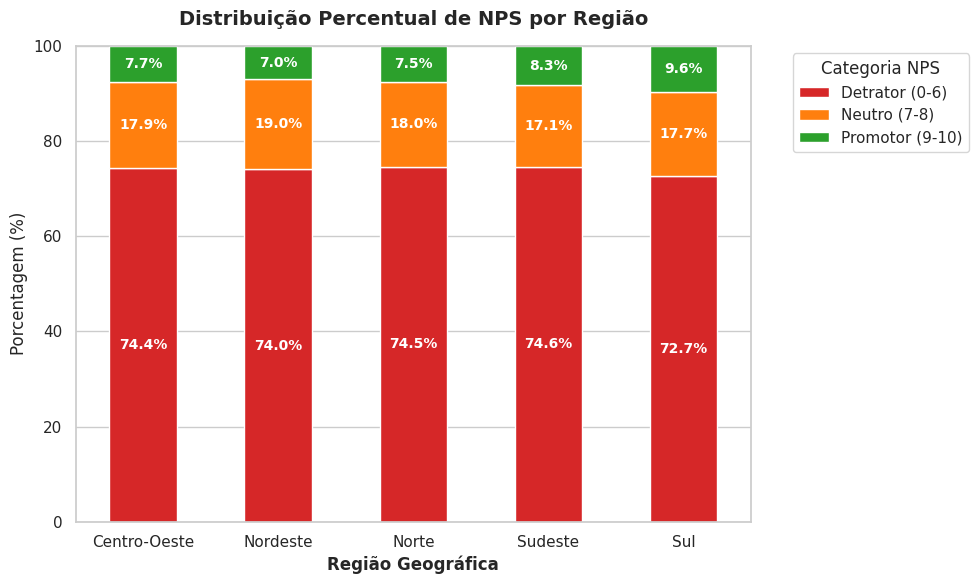

In [75]:
# Configuração visual
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gráfico de barras empilhadas
ax = tabela_percentual.plot(
    kind='bar',
    stacked=True,
    color=['#d62728', '#ff7f0e', '#2ca02c'],
    figsize=(10, 6)
)

# Adicionar os valores percentuais dentro das barras
for container in ax.containers:
    for patch in container:
        height = patch.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}%',
                (patch.get_x() + patch.get_width() / 2, patch.get_y() + height / 2),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white'
            )

plt.title('Distribuição Percentual de NPS por Região', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Região Geográfica', fontsize=12, fontweight='bold')
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Categoria NPS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

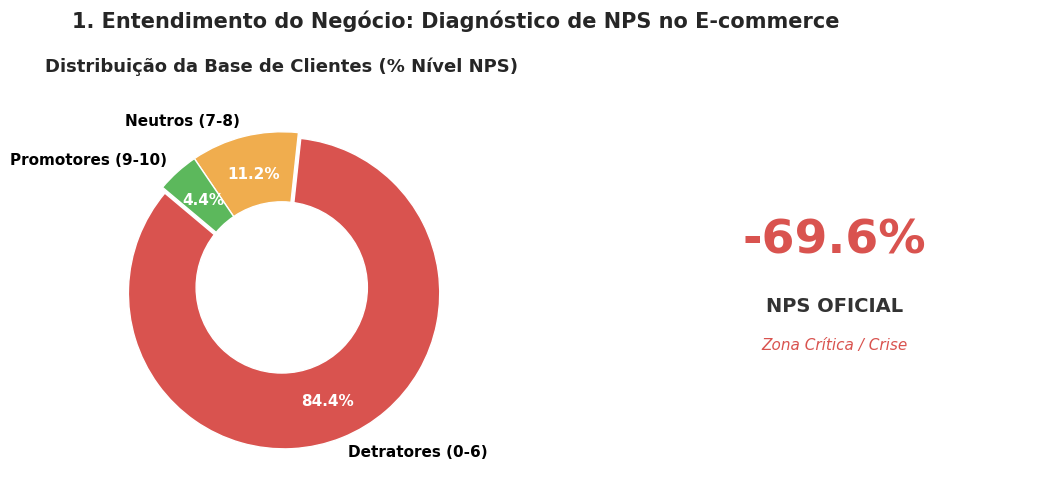

In [76]:



# Configuração visual do tema
sns.set_theme(style="whitegrid")

# 1. Dados do Entendimento do Negócio
categorias = ['Detratores (0-6)', 'Neutros (7-8)', 'Promotores (9-10)']
porcentagens = [84.4, 11.2, 4.4]
cores = ['#d9534f', '#f0ad4e', '#5cb85c']  # Vermelho (Detração), Laranja (Neutro), Verde (Promotor)

# 2. Criar a estrutura  (Gráfico + KPI Card)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})

# Subplot 1: Gráfico de Rosca (Distribuição da Base)
wedges, texts, autotexts = ax1.pie(
    porcentagens,
    labels=categorias,
    autopct='%1.1f%%',
    startangle=140,
    colors=cores,
    pctdistance=0.75,
    explode=(0.04, 0, 0),
    textprops=dict(color="black", fontsize=11, weight="bold")
)

# Adicionar círculo central para formar a rosca
centre_circle = plt.Circle((0,0), 0.55, fc='white')
ax1.add_artist(centre_circle)

# Ajustar rótulos percentuais dentro da rosca
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

ax1.set_title('Distribuição da Base de Clientes (% Nível NPS)', fontsize=13, pad=15, weight='bold')

# Subplot 2: Card Executivo de KPI (NPS Geral)
ax2.axis('off')



# Textos dentro do Card
ax2.text(0.5, 0.62, '-69.6%', ha='center', va='center', fontsize=34, weight='bold', color='#d9534f')
ax2.text(0.5, 0.45, 'NPS OFICIAL', ha='center', va='center', fontsize=14, weight='bold', color='#333333')
ax2.text(0.5, 0.35, 'Zona Crítica / Crise', ha='center', va='center', fontsize=11, style='italic', color='#d9534f')

# Título Principal do Painel
plt.suptitle('1. Entendimento do Negócio: Diagnóstico de NPS no E-commerce', fontsize=15, weight='bold', y=0.98)

plt.tight_layout()
plt.show()